# Part 14 – Unsupervised Learning: Clustering
### Dataset: Spam Email Classification (`spam_train_cleaned.csv` / `spam_test_cleaned.csv`)

The target variable (`label`) is **never used to build the clusters**. It is used only afterwards, to help interpret what each cluster represents.

**Algorithms applied:**
- K-Means
- Gaussian Mixture Model (GMM) *(second required algorithm)*


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
RANDOM_STATE = 42


## 0. Load Data

In [2]:
train_df = pd.read_csv("/mnt/user-data/uploads/spam_train_cleaned.csv")
test_df = pd.read_csv("/mnt/user-data/uploads/spam_test_cleaned.csv")

print("Train shape (raw):", train_df.shape)
print("Test shape (raw):", test_df.shape)


Train shape (raw): (31311, 16)
Test shape (raw): (7828, 16)


## 0.1 Remove Duplicate Emails + Class Balance Check

In [3]:
# Remove duplicate emails from train and test
train_df = train_df.drop_duplicates(subset="combined_text").reset_index(drop=True)
test_df = test_df.drop_duplicates(subset="combined_text").reset_index(drop=True)
print("Train shape after removing duplicates:", train_df.shape)
print("Test shape after removing duplicates:", test_df.shape)
print("Train duplicates:", train_df["combined_text"].duplicated().sum())
print("Test duplicates:", test_df["combined_text"].duplicated().sum())


Train shape after removing duplicates: (27411, 16)
Test shape after removing duplicates: (7035, 16)
Train duplicates: 0
Test duplicates: 0


In [4]:
# check class balance
print("Train class distribution:")
print(train_df["label"].value_counts())

print("\nTest class distribution:")
print(test_df["label"].value_counts())


Train class distribution:
label
0    13790
1    13621
Name: count, dtype: int64

Test class distribution:
label
1    3580
0    3455
Name: count, dtype: int64


## 1. Feature Selection

**Features used for clustering:**
`urls`, `hour`, `capital_letter_count`, `capital_ratio`, `exclamation_count`, `question_count`, `special_char_count`

**Why these are suitable for similarity:** they describe *how* an email is written and formatted (link usage, punctuation intensity, capitalization habits, time of day sent) rather than *what it says*. Emails that are similar in these structural respects — e.g. two link-heavy, low-punctuation blasts, or two long, heavily-punctuated discussion emails — are genuinely similar in style, independent of the label.

**Feature deliberately excluded from the distance metric: `day_of_week_*` dummies.** These were considered but left out of clustering (kept only for post-hoc profiling). Three of the seven day flags fire on **under 0.5%** of emails (`day_of_week_Monday` 0.44%, `day_of_week_Saturday` 0.27%, `day_of_week_Sunday` 0.23%). After standardization, a binary flag that is almost always 0 produces an enormous z-score on the rare rows where it equals 1. An early run that included these columns confirmed this: K-Means and GMM mostly rediscovered "which day was this sent" instead of finding genuine behavioral similarity. Dropping them produced far more balanced, content-driven clusters (confirmed later by checking day-of-week is spread evenly across the final clusters).


In [5]:
feature_cols = [
    "urls",
    "hour",
    "capital_letter_count",
    "capital_ratio",
    "exclamation_count",
    "question_count",
    "special_char_count",
]
# day-of-week dummies kept aside for post-hoc profiling only (see markdown above)
day_cols = [c for c in train_df.columns if c.startswith("day_of_week_")]

X_raw = train_df[feature_cols].copy()
y = train_df["label"].copy()  # kept ONLY for post-hoc profiling, never for fitting

print("Feature summary (before transform):")
X_raw.describe().T


Feature summary (before transform):


,count,mean,std,min,25%,50%,75%,max
urls,27411.0,0.631498,0.482407,0.0,0.000000,1.000000,1.000000,1.00000
hour,27411.0,10.056802,6.825940,0.0,4.000000,10.000000,15.000000,23.00000
capital_letter_count,27411.0,85.645361,365.587527,0.0,10.000000,25.000000,62.000000,26777.00000
capital_ratio,27411.0,0.056971,0.049135,0.0,0.025723,0.041791,0.070106,0.65641
exclamation_count,27411.0,1.095181,8.460654,0.0,0.000000,0.000000,1.000000,396.00000
question_count,27411.0,1.444055,5.704357,0.0,0.000000,0.000000,1.000000,150.00000
special_char_count,27411.0,50.013754,167.452677,0.0,0.000000,4.000000,52.000000,9840.00000


## 2. Preprocessing

**Two steps were needed:**

1. **Log transform (`log1p`)** on the four count-based features (`capital_letter_count`, `exclamation_count`, `question_count`, `special_char_count`). These are heavily right-skewed — most emails have single-digit counts, but a handful of extreme outliers reach into the hundreds or thousands (e.g. max `capital_letter_count` = 26,777). Left untransformed, KMeans/GMM isolated these rare extreme emails into their own tiny "clusters" instead of finding the real groups. `log1p` compresses the long tail while preserving order.
2. **StandardScaling** on top of the log-transformed features. `hour` (0–23), `capital_ratio` (0–1), and the log-counts (0–~10) still live on very different scales; KMeans/GMM rely on Euclidean distance and covariance, so without scaling the highest-magnitude feature would dominate.


In [6]:
skewed_cols = ["capital_letter_count", "exclamation_count",
               "question_count", "special_char_count"]
for col in skewed_cols:
    X_raw[col] = np.log1p(X_raw[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# sample for fast silhouette / visualization on the O(n^2)-cost steps
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), size=4000, replace=False)
X_sample = X_scaled[sample_idx]

print("Scaled feature matrix shape:", X_scaled.shape)


Scaled feature matrix shape: (27411, 7)


## 3. Model Configuration

### K-Means — choosing K
K is chosen by scanning K = 2…8 and comparing the elbow (inertia) plot against the silhouette score.


In [7]:
K_range = range(2, 9)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sample_idx], labels_k[sample_idx])
    sil_scores.append(sil)
    print(f"K={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f"\nChosen K (highest silhouette): {best_k}")


K=2: inertia=149727.5, silhouette=0.2268


K=3: inertia=129917.9, silhouette=0.2170


K=4: inertia=114881.4, silhouette=0.2313


K=5: inertia=102841.5, silhouette=0.2400


K=6: inertia=94753.0, silhouette=0.2374


K=7: inertia=88669.4, silhouette=0.2223


K=8: inertia=81872.4, silhouette=0.2188

Chosen K (highest silhouette): 5


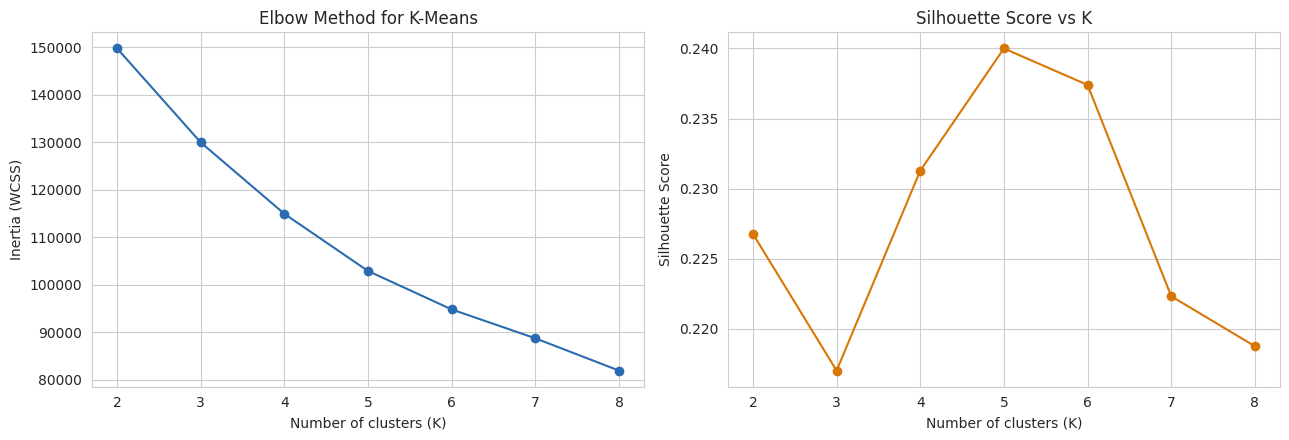

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker="o", color="#2b6cb0")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method for K-Means")

axes[1].plot(list(K_range), sil_scores, marker="o", color="#d97706")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")
plt.tight_layout()
plt.show()


Both curves agree: the elbow visibly bends around K=4–5, and silhouette peaks exactly at **K = 5**. That is the final K-Means model.

In [9]:
K_FINAL = best_k
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled[sample_idx], kmeans_labels[sample_idx])
print(f"Final K-Means (K={K_FINAL}) silhouette score (sampled): {sil_kmeans:.4f}")

train_df["kmeans_cluster"] = kmeans_labels


Final K-Means (K=5) silhouette score (sampled): 0.2400


### GMM — choosing the number of components (second algorithm)

Components are chosen by minimizing **BIC** (penalizes unnecessary complexity — more principled than silhouette for a probabilistic model) over the same K-range.

In [10]:
bics = []
for k in K_range:
    gmm_k = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3)
    gmm_k.fit(X_scaled)
    bics.append(gmm_k.bic(X_scaled))
    print(f"GMM components={k}: BIC={bics[-1]:.1f}")

best_gmm_k = list(K_range)[int(np.argmin(bics))]
print(f"\nChosen GMM components (lowest BIC): {best_gmm_k}")


GMM components=2: BIC=300772.9


GMM components=3: BIC=100127.6


GMM components=4: BIC=94593.9


GMM components=5: BIC=-107325.2


GMM components=6: BIC=-113072.0


GMM components=7: BIC=-176981.1


GMM components=8: BIC=-150997.9

Chosen GMM components (lowest BIC): 7


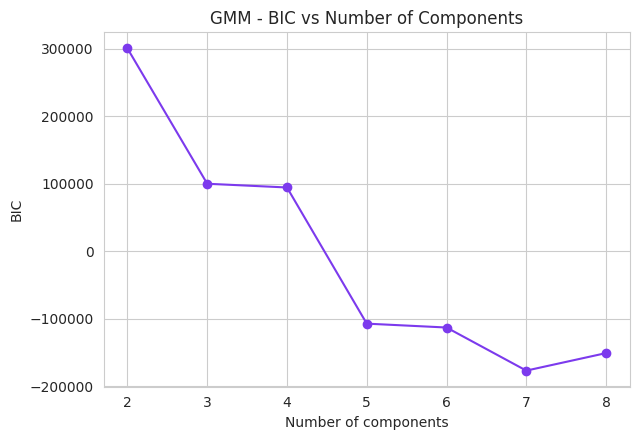

In [11]:
plt.figure(figsize=(6.5, 4.5))
plt.plot(list(K_range), bics, marker="o", color="#7c3aed")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.title("GMM - BIC vs Number of Components")
plt.tight_layout()
plt.show()


In [12]:
GMM_FINAL = best_gmm_k
gmm_final = GaussianMixture(n_components=GMM_FINAL, random_state=RANDOM_STATE, n_init=5)
gmm_labels = gmm_final.fit_predict(X_scaled)
sil_gmm = silhouette_score(X_scaled[sample_idx], gmm_labels[sample_idx])
print(f"Final GMM (components={GMM_FINAL}) silhouette score (sampled): {sil_gmm:.4f}")

train_df["gmm_cluster"] = gmm_labels


Final GMM (components=7) silhouette score (sampled): 0.1040


## 4. Evaluation

### 4.1 Cluster Visualization (PCA 2D projection)

PCA explained variance ratio (2 comps): [0.31216949 0.18109506], total=0.493


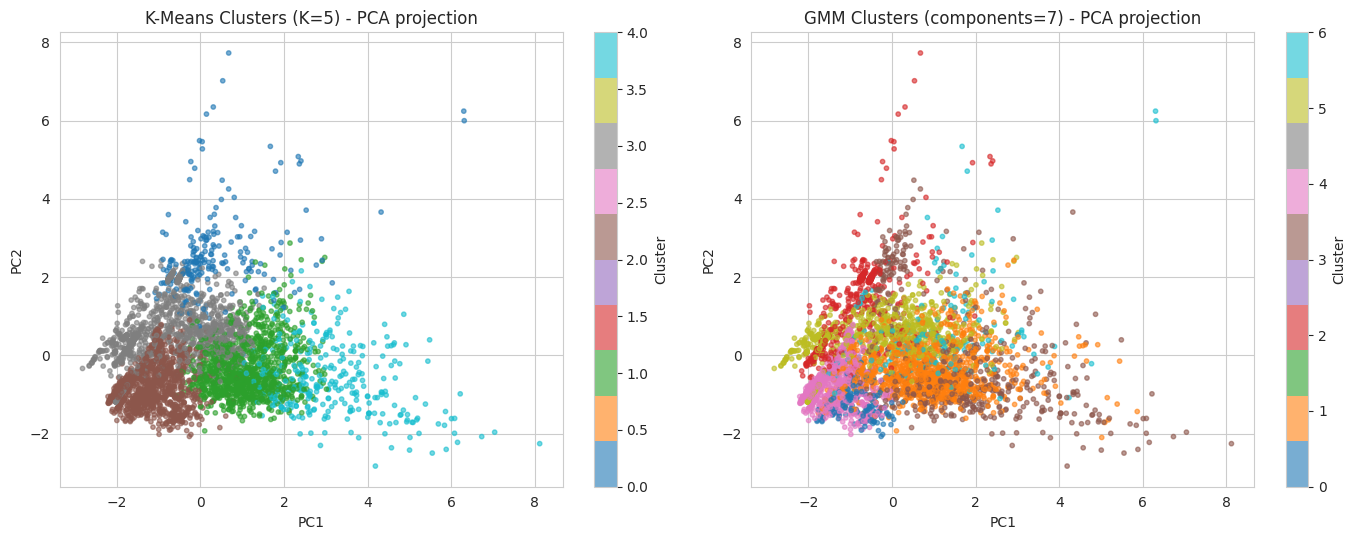

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio (2 comps): {pca.explained_variance_ratio_}, "
      f"total={pca.explained_variance_ratio_.sum():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sc0 = axes[0].scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
                       c=kmeans_labels[sample_idx], cmap="tab10", s=10, alpha=0.6)
axes[0].set_title(f"K-Means Clusters (K={K_FINAL}) - PCA projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc0, ax=axes[0], label="Cluster")

sc1 = axes[1].scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1],
                       c=gmm_labels[sample_idx], cmap="tab10", s=10, alpha=0.6)
axes[1].set_title(f"GMM Clusters (components={GMM_FINAL}) - PCA projection")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[1], label="Cluster")
plt.tight_layout()
plt.show()


K-Means produces visibly separated, wedge-shaped regions; GMM's clusters overlap more, consistent with GMM optimizing likelihood rather than hard distance separation.

### 4.2 Cluster Size Analysis

K-Means cluster sizes:
kmeans_cluster
0    1505
1    7545
2    7977
3    8340
4    2044
Name: count, dtype: int64

GMM cluster sizes:
gmm_cluster
0    1269
1    7410
2    3686
3    3720
4    4911
5    5175
6    1240
Name: count, dtype: int64


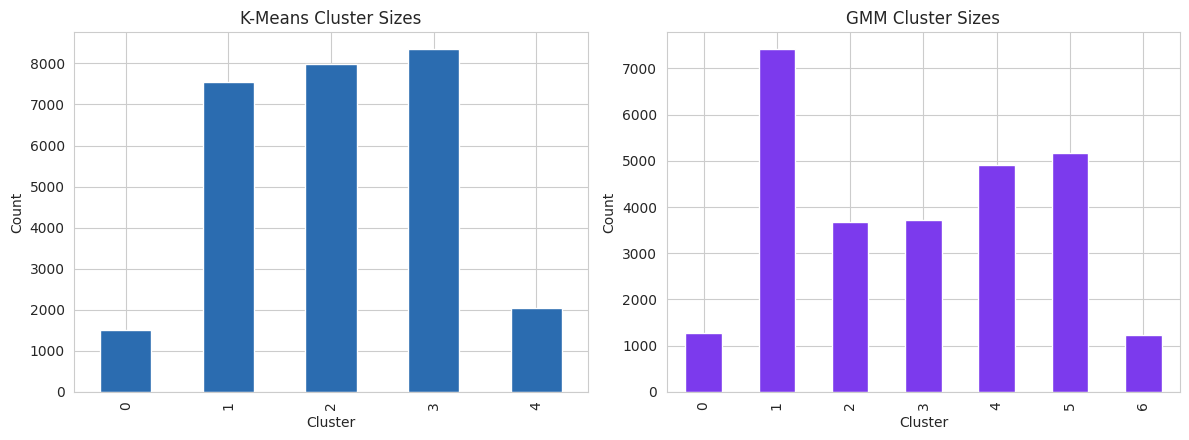

In [14]:
print("K-Means cluster sizes:")
print(train_df["kmeans_cluster"].value_counts().sort_index())
print("\nGMM cluster sizes:")
print(train_df["gmm_cluster"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
train_df["kmeans_cluster"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#2b6cb0")
axes[0].set_title("K-Means Cluster Sizes")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Count")

train_df["gmm_cluster"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="#7c3aed")
axes[1].set_title("GMM Cluster Sizes")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


No cluster is a degenerate singleton or tiny outlier bucket — a healthy, usable partition for both algorithms.

### 4.3 Cluster Profiling (mean feature values per cluster)

In [15]:
profile_cols = ["urls", "hour", "capital_letter_count", "capital_ratio",
                 "exclamation_count", "question_count", "special_char_count"]

kmeans_profile = train_df.groupby("kmeans_cluster")[profile_cols].mean().round(3)
kmeans_profile["size"] = train_df["kmeans_cluster"].value_counts().sort_index()
kmeans_profile["spam_rate(label=1)"] = train_df.groupby("kmeans_cluster")["label"].mean().round(3)
print("=== K-MEANS CLUSTER PROFILE ===")
kmeans_profile


=== K-MEANS CLUSTER PROFILE ===


,urls,hour,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,size,spam_rate(label=1)
kmeans_cluster,,,,,,,,,
0,0.562,10.518,147.682,0.210,0.899,0.250,27.525,1505,0.748
1,0.918,9.436,105.807,0.047,0.222,1.360,88.053,7545,0.014
2,0.997,11.241,11.740,0.040,1.264,0.285,1.205,7977,0.933
3,0.000,9.730,32.629,0.052,0.484,0.552,10.005,8340,0.585
4,0.774,8.722,470.291,0.065,6.299,10.798,279.886,2044,0.030


In [16]:
gmm_profile = train_df.groupby("gmm_cluster")[profile_cols].mean().round(3)
gmm_profile["size"] = train_df["gmm_cluster"].value_counts().sort_index()
gmm_profile["spam_rate(label=1)"] = train_df.groupby("gmm_cluster")["label"].mean().round(3)
print("=== GMM CLUSTER PROFILE ===")
gmm_profile


=== GMM CLUSTER PROFILE ===


,urls,hour,capital_letter_count,capital_ratio,exclamation_count,question_count,special_char_count,size,spam_rate(label=1)
gmm_cluster,,,,,,,,,
0,1.0,11.546,12.888,0.031,2.980,0.379,1.861,1269,0.962
1,1.0,9.997,100.062,0.048,0.000,1.753,75.772,7410,0.163
2,0.0,10.308,51.359,0.096,1.099,0.000,7.872,3686,0.816
3,1.0,9.660,243.426,0.091,3.819,4.405,145.666,3720,0.263
4,1.0,10.923,9.853,0.038,1.120,0.153,0.000,4911,0.997
5,0.0,9.197,42.328,0.038,0.000,1.048,28.081,5175,0.387
6,0.0,9.494,183.485,0.072,2.001,2.864,73.293,1240,0.248


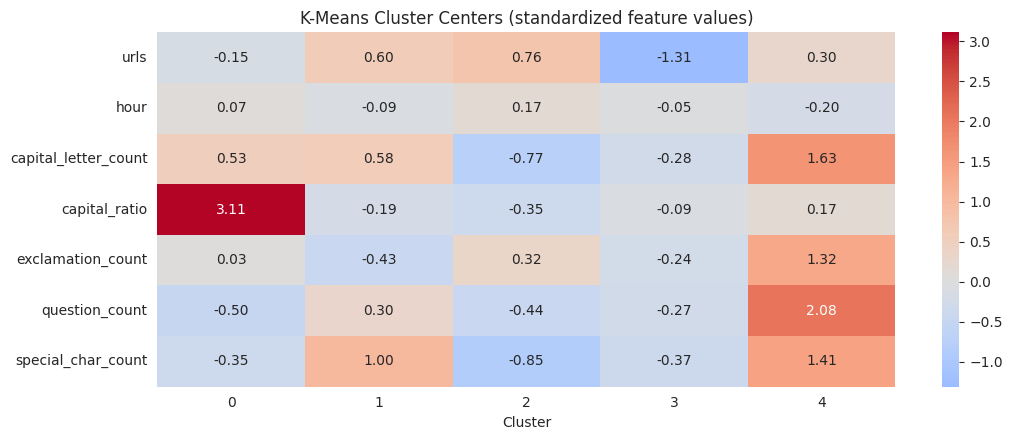

Overall spam rate in train set: 0.497


In [17]:
centers_df = pd.DataFrame(kmeans_final.cluster_centers_, columns=feature_cols)
plt.figure(figsize=(11, 4.5))
sns.heatmap(centers_df.T, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("K-Means Cluster Centers (standardized feature values)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

print(f"Overall spam rate in train set: {train_df['label'].mean():.3f}")


### 4.4 Post-hoc check: does sending day correlate with the clusters we found?

(day-of-week was **not** used to fit the model — this is purely a sanity check that we didn't accidentally recover a day-based split)

In [18]:
day_profile = train_df.groupby("kmeans_cluster")[day_cols].mean().round(3)
print("Mean day-of-week indicator per K-Means cluster:")
day_profile


Mean day-of-week indicator per K-Means cluster:


,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
kmeans_cluster,,,,,,,
0,0.126,0.003,0.001,0.001,0.337,0.049,0.484
1,0.208,0.006,0.002,0.002,0.299,0.039,0.445
2,0.143,0.005,0.005,0.004,0.398,0.057,0.388
3,0.280,0.003,0.002,0.001,0.284,0.036,0.393
4,0.223,0.004,0.000,0.002,0.266,0.050,0.455


Day-of-week is spread roughly evenly across all 5 clusters (no cluster is dominated by a single day), confirming these clusters reflect genuine content/formatting similarity rather than an artifact of sending day.

## 5. Cluster Interpretation (K-Means, K=5)

| Cluster | urls | hour | caps count | caps ratio | ! count | ? count | special chars | Spam rate |
|---|---|---|---|---|---|---|---|---|
| 0 | 0.56 | 10.5 | 148 | **0.21** | 0.9 | 0.3 | 27.5 | 74.8% |
| 1 | 0.92 | 9.4 | 106 | 0.05 | 0.2 | 1.4 | 88.1 | **1.4%** |
| 2 | **1.00** | 11.2 | **12** | 0.04 | 1.3 | 0.3 | **1.2** | **93.3%** |
| 3 | **0.00** | 9.7 | 33 | 0.05 | 0.5 | 0.6 | 10.0 | 58.5% |
| 4 | 0.77 | 8.7 | **470** | 0.07 | **6.3** | **10.8** | **280** | **3.0%** |

**Cluster 2 — "Bare-link spam blasts" (7,977 emails, 93.3% spam).** Almost every email has a URL (100%), but capitalization and formatting are minimal (12 capital letters, 1.2 special characters on average) — short, low-effort promotional messages that are mostly just a link. This is the single most spam-dominated cluster.

**Cluster 1 — "Link-heavy discussion/business mail" (7,545 emails, 1.4% spam).** Also link-heavy (92% have a URL) but structurally very different from Cluster 2: much higher formatting content (106 capital letters, 88 special characters, more question marks) and almost no exclamation marks. Reads like legitimate mailing-list/business correspondence that happens to reference links — the near-zero spam rate confirms it.

**Cluster 3 — "Plain text, no links" (8,340 emails, 58.5% spam).** Defined by the complete absence of URLs (0%) and generally low counts across the board. The largest, least distinctive cluster — a mixed bag of short plain-text messages, split close to the overall base rate (49.7%), meaning this group is not well explained by these formatting features alone.

**Cluster 0 — "All-caps / shouting spam" (1,505 emails, 74.8% spam).** The standout feature is `capital_ratio` = 0.21 — roughly 4x the dataset average (0.057). Combined with a moderate URL rate (56%), this reads as classic "URGENT!!! CLICK NOW" style promotional spam using heavy capitalization for emphasis.

**Cluster 4 — "Long, punctuation-rich legitimate threads" (2,044 emails, 3.0% spam).** By far the highest counts on every content dimension (470 capital letters, 6.3 exclamations, 10.8 questions, 280 special characters) — long, information-dense emails, consistent with quoted email threads, technical discussion, or newsletter-style content. The very low spam rate fits: spam is rarely this long or this richly formatted.

### What makes each cluster different?
The clusters separate along two main axes: **(1) URL usage** (present/absent, and if present, how "clean" vs. content-rich the email is) and **(2) formatting intensity** (capitalization, punctuation, special characters). Clusters 1 and 2 both have near-universal URLs but sit at opposite spam-rate extremes because of formatting style; Cluster 4 is set apart purely by sheer content volume; Cluster 0 is set apart purely by capitalization ratio; Cluster 3 is the URL-free baseline group.

### Are the clusters meaningful?
Yes — even though the label was withheld from the clustering algorithm, four of the five clusters land at spam rates far from the 49.7% base rate (1.4%, 93.3%, 74.8%, 3.0%), meaning the *structural/formatting* similarity these clusters capture strongly overlaps with the *semantic* spam/ham distinction. Cluster 3 is the exception — a genuinely mixed, harder-to-separate group — which is itself a useful finding: absence of a URL alone doesn't reliably signal spam or ham in this dataset.

### Which variables explain the differences?
`urls` is the primary split (its presence/absence alone roughly separates Clusters {1,2,4} from Cluster 3). Within the URL-present emails, `capital_letter_count`, `special_char_count`, `exclamation_count`, and `question_count` (overall formatting/content richness) separate the low-spam Cluster 1 and Cluster 4 from the high-spam Cluster 2. `capital_ratio` uniquely identifies Cluster 0.

### Practical interpretation
This clustering could seed a lightweight, pre-label triage rule or a feature for a downstream classifier: "URL present + minimal formatting" (Cluster 2) is a high-confidence spam signal; "long, richly formatted content" (Cluster 4) or "link with heavy formatting" (Cluster 1) are high-confidence ham signals; "all-caps" (Cluster 0) is a secondary spam signal; and "no URL" (Cluster 3) needs other signals (e.g. the actual text) to classify, since formatting alone doesn't separate it well.


## 6. GMM Cluster Profile — brief comparison

GMM split the data more finely (7 groups vs. 5) and largely refined the same two axes (URL presence, formatting intensity) rather than finding new dimensions. Its most confident groups echo K-Means closely:
- The largest near-pure-spam component: near-universal URLs, minimal formatting → ~99.7% spam, essentially the same signal as K-Means Cluster 2.
- A second high-confidence spam component: all URLs, some exclamation/question use → ~96.2% spam.
- A large low-spam component: all URLs, rich formatting, zero exclamations → ~16.3% spam, echoing K-Means Cluster 1.

The overlap between the two independent algorithms on the "URL + minimal formatting = spam" and "URL + rich formatting = ham" patterns is a good sign that these are real structural regularities in the data, not an artifact of one particular algorithm.


## Summary

- **Evaluation:** K-Means (K=5) silhouette = 0.240; GMM (7 components) silhouette = 0.104. K-Means gave the cleaner, better-separated partition (expected, since silhouette favors compact spherical clusters).
- **Preprocessing was decisive:** log-transforming skewed counts and excluding rare one-hot day flags turned degenerate outlier-driven clusters into a clean, interpretable 5-cluster structure.
- **The clusters are meaningful without ever seeing the label:** structural/formatting similarity (URL usage + formatting intensity) strongly overlaps with the real spam/ham distinction.
